Introdução

Representação de grafos

In [1]:
from collections import deque

# Class Vertice
class Vertex:
    ''' Estrutura de Vértice para um grafo: encapsula um elemento (vertex_id) 
        que é o identificador deste nó.
        
        O elemento (vertex_id) deve ser hashable:  
        - Um objeto hashable é aquele que pode ser utilizado como uma chave num dicionário Python.
        - Isto inclui strings, números, tuplas, etc.
    '''
    
    def __init__(self, vertex_id):
        '''O vértice será inserido no Grafo usando o método insert_vertex(x) que cria um Vertex'''
        self._vertex_id = vertex_id   # Id do vértice (elemento a inserir no grafo)
        
    def __hash__(self):
        '''O valor do elemento é usado como hash para o vértice (o elemento deve ser hashable)'''
        return hash(self._vertex_id)  # devolve o hash do elemento

    def __str__(self):
        '''Devolve a representação do objeto vértice em string.'''
        return'v{0}'.format(self._vertex_id)

    def __eq__(self, vertex):
        if isinstance(vertex, Vertex):
            return self._vertex_id == vertex._vertex_id
        return False # Deve-se garantir que: se hash(vertex)==hash(self), entao vertex==self

    def __lt__(self, vertex):
        return self.vertex_id < vertex._vertex_id
    
    def __le__(self, vertex):
        return self.self._vertex_id <= vertex._vertex_id
    
    def __gt__(self, vertex):
        return self._vertex_id > vertex._vertex_id
    
    def __ge__(self, vertex):
        return self._vertex_id >= vertex._vertex_id
    
    def vertex_id(self):
        ''' Devolve o elemento guardado neste vértice.'''
        return self._vertex_id

In [2]:
# Class Edge
class Edge:
    ''' Estrutura de Aresta para um Grafo: (origem, destino) e peso '''

    def __init__(self, vertex_1, vertex_2, weight):
        self._vertex_1 = vertex_1
        self._vertex_2 = vertex_2
        self._weight = weight

    def __hash__(self):
        # Função que mapeia a aresta a uma posição no dicionário (hash map)
        return hash( (self._vertex_1, self._vertex_2) )

    def __str__(self):
        ''' Devolve a representação do objeto aresta em string: (origem, destino)w=peso '''
        return'e({0},{1})w={2}'.format(self._vertex_1, self._vertex_2, self._weight)

    def __eq__(self, other):
        # define igualdade de duas arestas (deve ser consistente com a função hash)
        return self._vertex_1 == other._vertex_1 and self._vertex_2 == other._vertex_2

    def endpoints(self):
        ''' Devolve a tupla (vertex_1, vertex_2) os vértices adjacentes vertex_1 e vertex_2.'''
        return (self._vertex_1, self._vertex_2)

    def cost(self):
        ''' Devolve o peso associado a este arco.'''
        return self._weight
    
    def opposite(self, vertex):
        ''' Indica o vértice oposto ao vertex nesta aresta 
            (apenas se vertex fizer parte da aresta).'''
        if vertex == self._vertex_1:
            return self._vertex_2
        elif vertex == self._vertex_2:
            return self._vertex_1
        else:
            return None

In [3]:
class Graph:
    '''
    Representação de um grafo usando dicionários encadeados (nested dictionaries).
    
    Atributos:
    ----------
    adjancencies: Dicionário externo que associa um vértice (Vertex) a um  
                  mapa de adjacências (dicionario interno)
                  Em vez de utilizar uma estrutura com um array (como nos slides),
                  utiliza uma estrutura do tipo "dicionário de dicionários":
                  < vertex , < neighbor_vertex , edge > >
                  
    vertices: Dicionário auxiliar que associa o id dos vértices do grafo
              a um objeto Vertex (tabela de símbolos):
              < vertex_id , vertex >
              
    n: Número de vértices no Grafo
    m: Número de arestas no Grafo
    
    ----------
'''
    def __init__(self):
        '''Construtor: Cria um grafo vazio (dicionário de _adjancencies).'''
        self._adjancencies = {}  # dicionário que associa o par chave-valor: <Vertex v, Mapa de adjacências de v> 
        self._vertices = {}      # dicionário que associa o par: <id do vértice, objeto Vertex correspondente> 
        self._n = 0              # número de vértices do grafo
        self._m = 0              # número de arestas do grafo
        
    def __str__(self):
        '''Devolve a representação do grafo em string (toString)'''
        if self._n == 0:
            ret = "DAA-Graph: <empty>\n"
        else:
            ret = "DAA-Graph:\n"
            for vertex in self._adjancencies.keys():
                #ret += "vertex-"
                ret += str(vertex) + ": "
                for edge in self.incident_edges(vertex.vertex_id()):
                    ret += str(edge) + "; "
                ret += "\n"
        return ret
    
    def is_directed(self):
        '''A classe Graph representa um grafo não orientado.'''
        return False
    
    def order(self):
        '''Ordem de um grafo: a quantidade de vértices no Grafo.'''
        return self._n
    
    def size(self):
        '''Dimensão de um grafo: a quantidade total de arestas do Grafo.'''
        return self._m 
    
    def has_vertex(self, vertex_id):
        '''Verifica se o vértice de id vertex_id está no grafo.'''
        return vertex_id in self._vertices
    
    def has_edge(self, u_id, v_id):
        '''Verifica se a aresta (u_id, v_id) existe no grafo.'''
        if not self.has_vertex(u_id) or not self.has_vertex(v_id):
            return False
        else:
            vertex_u = self._vertices[u_id]
            vertex_v = self._vertices[v_id]
            return vertex_v in self._adjancencies[vertex_u]
        
    def insert_vertex(self, vertex_id):
        '''Insere um novo vértice com o id vertex_id.'''
        if not self.has_vertex(vertex_id):
            vertex = Vertex(vertex_id)          # instancia um objeto do tipo Vertex
            self._vertices[vertex_id] = vertex  # insere o novo vértice no dicionário de vertices
            self._adjancencies[vertex] = {}     # inicializa o mapa de adjacências deste vértice a vazio
            self._n +=1                         # mais um vértice no grafo

    def insert_edge(self, u_id, v_id, weight=0):
        ''' Cria e insere uma nova aresta entre u_id e v_id com peso weight.
            Se a aresta já existe no grafo, atualiza-se o seu peso.
            Também insere os vértices u_id e v_id, caso não existam.'''
        if not self.has_vertex(u_id):
            self.insert_vertex(u_id) # insere novo vertex e atualiza n
        if not self.has_vertex(v_id):
            self.insert_vertex(v_id) # insere novo vertex e atualiza n      
        if not self.has_edge(u_id, v_id):
            self._m +=1           # atualiza m apenas se a aresta ainda não existir no grafo
        else:
            print(f"Existing edge {u_id} and {v_id}. Will only update weight")
        vertex_u = self._vertices[u_id]  # acede ao objeto Vertex associado a u_id
        vertex_v = self._vertices[v_id]  # acede ao objeto Vertex associado a v_id
        e = Edge(vertex_u, vertex_v, weight)    
        self._adjancencies[vertex_u][vertex_v] = e  # coloca v nas adjacências de u
        self._adjancencies[vertex_v][vertex_u] = e  # e u nas adjacências de v (para facilitar a procura de todas as arestas incidentes num vértice)
    
    def degree(self, vertex_id):
        '''Quantidade de arestas incidentes no vértice v.
        '''
        return len(self._adjancencies[self._vertices[vertex_id]])
    
    def get_vertex(self, vertex_id):
        ''' Devolve o objeto Vertex associado ao elemento vertex_id no grafo
        '''
        return None if not self.has_vertex(vertex_id) else self._vertices[vertex_id] 
    
    def get_edge(self, u_id, v_id):
        ''' Devolve o objeto aresta (Edge) que liga u_id a v_id. 
            Devolve None se não forem adjacentes ou se (um d)os vértices não existirem.'''  
        if not self.has_edge(u_id, v_id):
            return None
        else:
            vertex_u = self._vertices[u_id]
            vertex_v = self._vertices[v_id]
            return self._adjancencies[vertex_u][vertex_v]
    
    def vertices(self):
        '''Devolve um iterável sobre todos os vértices do Grafo (tipo Vertex)'''
        return self._vertices.values()

    def edges(self):    
        '''Devolve um iterável sobre todas as arestas do Grafo (sem arestas duplicadas).'''
        seen = {}      # evita a repetição de arestas no grafo não orientado
        for adj_map in self._adjancencies.values():
            for edge in adj_map.values():
                if edge not in seen:
                    yield edge
                seen[edge] = True

    def incident_edges(self, vertex_id):
        '''Devolve um iterável (gerador) com todas as arestas de um vértice com id vertex_id.'''
        vertex = self._vertices[vertex_id]
        for edge in self._adjancencies[vertex].values(): # para todas as arestas incidentes em v:
            yield edge

    def has_neighbors(self, vertex_id):
        '''Verifica se o vértice de id vertex_id tem vértices adjacentes (vizinhos).'''
        if not self.has_vertex(vertex_id):
            return False
        return self.degree(vertex_id) > 0
    
    def remove_vertex(self, vertex_id):
        '''Remove o vértice com id vertex_id. Se o vértice não existir, não faz nada.'''
        # Passo 1: remover todas as arestas do vértice dado
        # Passo 2: remover todas as arestas incidentes em vertex_id dos mapas de outros vertices
        # Passo 3: remover o vértice com id vertex_id do grafo
        # Passo 4: decrementa contador de vértices
        if self.has_vertex(vertex_id):
            lst_copied = list(self.incident_edges(vertex_id)) # copia para a lista para evitar erros de concorrência (remove enquanto itera na lista)
            for edge in lst_copied:
                x, y = edge.endpoints()
                self.remove_edge(x.vertex_id(),y.vertex_id())  # (Passos 1 e 2)
            del self._adjancencies[self._vertices[vertex_id]]  # (Passo 3 - remove do dicionário de adjacências)
            del self._vertices[vertex_id]                      # (Passo 3 - remove do dicionário de vértices)
            self._n -=1                                        # (Passo 4 - decrementa contador)
        
    def remove_edge(self, u_id, v_id):
        '''Remove a aresta entre u_id e v_id. Se a aresta não existir, não faz nada.'''
        if  self.has_edge(u_id, v_id):
            vertex_u = self._vertices[u_id]
            vertex_v = self._vertices[v_id]
            del self._adjancencies[vertex_u][vertex_v]
            if vertex_u != vertex_v:  # laços são removidos apenas uma vez
                del self._adjancencies[vertex_v][vertex_u]
            self._m -=1


API ConnectedComponents

In [4]:
class ConnectedComponents:
    
    def __init__(self, graph):
        self._marked = [False] * graph.order()
        self._graph = graph
        self._id = [None] * graph.order()
        
        self._count = 0
        for v in self._graph.vertices():
            if not self._marked[v.vertex_id()]:
                self._id[v.vertex_id()] = self._count
                self.dfs(v.vertex_id())
                self._count += 1

    def dfs(self, source):
        
        stack = deque()
        stack.append(source)

        while stack:
            v = stack.pop()
            self._id[v] = self._id[source]
            self._marked[v] = True
            for edge in self._graph.incident_edges(v):
                v2 = edge.opposite(self._graph.get_vertex(v))
                v2_id = v2.vertex_id()
                if not self._marked[v2_id]:
                    stack.append(v2_id)
        
    def connected(self, u, v):
        return self._id[u] == self._id[v]
    
    def component_id(self, v):
        return self._id[v]
    
    def count(self):
        return self._count
    
    def largest_component(self):
        
        largest_id = None
        count_comps = 0
        
        
        for i in range(self.count()):
            count = 0
            for j in self._graph.vertices():
                if self._id[j.vertex_id()] == i:
                    count += 1
            if count > count_comps:
                count_comps = count
                largest_id = i
        
        graph = Graph()
        for i in self._graph.vertices():
            if self._id[i.vertex_id()] == largest_id:
                graph.insert_vertex(i.vertex_id())

        for edge in self._graph.edges():
            (u, v) = edge.endpoints()

            if self._id[u.vertex_id()] == largest_id and self._id[v.vertex_id()] == largest_id:
                graph.insert_edge(u.vertex_id(), v.vertex_id())

        return graph



API CentralityAnalyzer

In [6]:
class CentralityAnalyzer:
    def __init__(self, graph: Graph):
        self._graph = graph
        self._num_comps = 0
        self._con_comps = None
        self._largest_comp = None
    
    def bfs(self, source):
        marked = {}
        parents = {}
        distTo = {}
        sigma = {}

        for v in self._graph.vertices():
            vid = v.vertex_id()
            marked[vid] = False
            parents[vid] = list()
            distTo[vid] = -1
            sigma[vid] = 0

        stack = deque()
        queue = deque()

        marked[source] = True
        queue.append(source)
        distTo[source] = 0
        sigma[source] = 1

        while queue:
            v = queue.popleft()
            stack.append(v)
            for edge in self._graph.incident_edges(v):
                v_obj = self._graph.get_vertex(v)          # converte int → Vertex
                v2 = edge.opposite(v_obj).vertex_id()      # devolve Vertex → extrai id
                if not marked[v2]:
                    marked[v2] = True
                    queue.append(v2)
                    parents[v2].append(v)
                    distTo[v2] = distTo[v] + 1
                    sigma[v2] = sigma[v]
                elif distTo[v2] == distTo[v] + 1:
                    sigma[v2] += sigma[v]
                    parents[v2].append(v)

        return parents, distTo, sigma, stack
    
    def num_components(self):
        if self._con_comps is None:
            self._con_comps = ConnectedComponents(self._graph)
        return self._con_comps.count()
    
    def largest_component(self):
        if self._largest_comp is None:
            if self._con_comps is None:
                self._con_comps = ConnectedComponents(self._graph)
            self._largest_comp = self._con_comps.largest_component()
        return self._largest_comp
    
    def degree_distribution(self):
        degree_dic = {}
        for v in self._graph.vertices():
            val = self._graph.degree(v.vertex_id())
            if val not in degree_dic:
                degree_dic[val] = 1
            else:
                degree_dic[val] += 1
        return degree_dic
    
    def diameter(self):
        graph = self.largest_component()
        largest_dist = 0
        for v in graph.vertices():
            (_, dist, _, _) = self.bfs(v.vertex_id())
            
            #Excentricidade: max d(v, v2)
            excentricity = 0
            for v2 in graph.vertices():
                val = dist[v2.vertex_id()]
                if val > excentricity:
                    excentricity = val
            if(excentricity > largest_dist):
                largest_dist = excentricity
        return largest_dist
    
    def degree_centrality(self):
        dc_dic = {}
        for v in self._graph.vertices():
            id = v.vertex_id()
            dc_dic[id] = self._graph.degree(id) / (self._graph.order() - 1)
        return dc_dic
    
    def closeness_centrality(self):
        cc_dic = {}
        for v in self._graph.vertices():
            (_, dist, _, _) = self.bfs(v.vertex_id())
            rv = 0
            sum = 0
            for d in dist.values():
                if d > 0:
                    rv += 1
                    sum += d
            if rv == 0:
                cc_dic[v.vertex_id()] = 0
            else:
                cc_dic[v.vertex_id()] = rv**2 / ((self._graph.order() - 1) * sum)
        return cc_dic
    
    def eigenvector_centrality(self):
        scores = {v.vertex_id(): 1 for v in self._graph.vertices()}
        new_scores = {}
        epsilon = 0.000001
        
        lc = self.largest_component()
        for it in range(100):
            new_scores = {}
            for v in lc.vertices():
                sum_v = 0
                for edge in self._graph.incident_edges(v.vertex_id()):
                    v_obj = self._graph.get_vertex(v.vertex_id())
                    v2    = edge.opposite(v_obj).vertex_id()
                    sum_v += scores[v2]    
                new_scores[v.vertex_id()] = sum_v
            max_s = max(new_scores.values())
            
            if max_s == 0:
                return new_scores, it + 1
            
            for v in self._graph.vertices():
                if lc.has_vertex(v.vertex_id()):
                    new_scores[v.vertex_id()] = new_scores[v.vertex_id()] / max_s
                else:
                    new_scores[v.vertex_id()] = 0
            
            if max(abs(new_scores[v.vertex_id()] - scores[v.vertex_id()]) for v in lc.vertices()) < epsilon:
                return new_scores, it + 1
            scores = new_scores.copy()
        
        return new_scores, it + 1
        
    def betweenness_centrality(self):
        n = self._graph.order()
        bc = {i.vertex_id(): 0 for i in self._graph.vertices()}
        
        for s in self._graph.vertices():
            delta = {i: 0 for i in range(n)}
            (parents, distTo, sigma, stack) = self.bfs(s.vertex_id())
            while stack:
                w = stack.pop()
                for parent in parents[w]:
                    delta[parent] += (sigma[parent] / sigma[w]) * (1 + delta[w])
                if s.vertex_id() != w:
                    bc[w] += delta[w]
        for vert in bc.keys():
            bc[vert] *= 2 / ((n - 1)*(n - 2))
        return bc

In [7]:
import csv

# ─────────────────────────────────────────────
# Função auxiliar: carrega um CSV para um Graph
# ─────────────────────────────────────────────
def load_graph_from_csv(filepath):
    """
    Lê um CSV com colunas Source, Target, weight e devolve:
    - graph      : objeto Graph com vertex_ids inteiros
    - id_to_name : dict {int → nome original}
    - name_to_id : dict {nome original → int}
    """
    name_to_id = {}
    id_to_name = {}
    graph = Graph()
    next_id = 0

    with open(filepath, newline='', encoding='utf-8') as f:
        reader = csv.DictReader(f)
        for row in reader:
            src_name = row['Source'].strip()
            tgt_name = row['Target'].strip()
            weight   = int(row['weight'])

            # Atribui um id inteiro a cada nome novo
            if src_name not in name_to_id:
                name_to_id[src_name] = next_id
                id_to_name[next_id]  = src_name
                next_id += 1
            if tgt_name not in name_to_id:
                name_to_id[tgt_name] = next_id
                id_to_name[next_id]  = tgt_name
                next_id += 1

            graph.insert_edge(name_to_id[src_name], name_to_id[tgt_name], weight)

    return graph, id_to_name, name_to_id


# ─────────────────────────────────────────────────────────────
# Função auxiliar: reconstrói o caminho entre source e target
# usando o dict parents devolvido pelo bfs()
# ─────────────────────────────────────────────────────────────
def reconstruct_path(parents, source_id, target_id):
    if source_id == target_id:
        return [source_id]
    
    path = []
    current = target_id
    
    while current != source_id:
        path.append(current)
        preds = parents[current]
        if not preds:
            return []   # sem caminho
        current = preds[0]
    
    path.append(source_id)
    path.reverse()
    return path


In [8]:
# ══════════════════════════════════════════════
#  SECÇÃO 2.2 — Conectividade
# ══════════════════════════════════════════════

datasets = {
    "got_book1": "got_book1.csv",
    "got_full":  "got_full.csv",
}

for ds_name, filepath in datasets.items():
    print("=" * 60)
    print(f"Dataset: {ds_name}")
    print("=" * 60)

    graph, id_to_name, name_to_id = load_graph_from_csv(filepath)
    analyzer = CentralityAnalyzer(graph)

    # ── Pergunta 1: O grafo é conexo? Quantas componentes? ──
    n_comps = analyzer.num_components()
    print(f"\n[1] Número de componentes conexas: {n_comps}")
    if n_comps == 1:
        print("    → O grafo É conexo.")
    else:
        print("    → O grafo NÃO é conexo.")

    # ── Pergunta 2: Tamanho da maior componente ──
    lc = analyzer.largest_component()
    lc_size = lc.order()
    print(f"\n[2] Tamanho (ordem) da maior componente conexa: {lc_size} vértices")

    # Personagens isolados (fora da maior componente)
    lc_ids = set(v.vertex_id() for v in lc.vertices())
    outside = [id_to_name[v.vertex_id()]
            for v in graph.vertices()
            if v.vertex_id() not in lc_ids]
    if outside:
        print(f"    Personagens fora da componente principal ({len(outside)}):")
        for name in sorted(outside):
            print(f"      - {name}")

    # ── Pergunta 3: Dois personagens à escolha — estão conectados? ──
    # Escolhemos dois personagens que sabemos existir nos datasets
    pairs = {
        "got_book1": ("Aggo", "Jon-Snow"),
        "got_full":  ("Daenerys-Targaryen", "Jon-Snow"),
    }
    char_a, char_b = pairs[ds_name]

    print(f"\n[3] Conectividade entre '{char_a}' e '{char_b}':")

    if char_a not in name_to_id or char_b not in name_to_id:
        print(f"    Um dos personagens não existe neste dataset.")
    else:
        id_a = name_to_id[char_a]
        id_b = name_to_id[char_b]

        # Verificação através do ConnectedComponents
        cc = analyzer._con_comps   # já calculado acima por num_components()
        if cc.connected(id_a, id_b):
            print(f"    → SIM, estão na mesma componente conexa.")
            # Caminho mais curto via BFS
            parents, distTo, _, _ = analyzer.bfs(id_a)
            dist = distTo[id_b]
            path_ids = reconstruct_path(parents, id_a, id_b)
            path_names = [id_to_name[pid] for pid in path_ids]
            print(f"    Distância: {dist} arestas")
            print(f"    Caminho: {' → '.join(path_names)}")
        else:
            print(f"    → NÃO, estão em componentes diferentes.")

    print()

# ── Pergunta 4: Comparação entre datasets ──
print("=" * 60)
print("Comparação da conectividade: got_book1 vs got_full")
print("=" * 60)

g1, id2n1, n2id1 = load_graph_from_csv("got_book1.csv")
g2, id2n2, n2id2 = load_graph_from_csv("got_full.csv")
a1 = CentralityAnalyzer(g1)
a2 = CentralityAnalyzer(g2)

lc1 = a1.largest_component()
lc2 = a2.largest_component()

print(f"\ngot_book1 → {g1.order()} vértices, {g1.size()} arestas, "
    f"{a1.num_components()} componente(s), maior: {lc1.order()} vértices "
    f"({100*lc1.order()/g1.order():.1f}%)")

print(f"got_full  → {g2.order()} vértices, {g2.size()} arestas, "
    f"{a2.num_components()} componente(s), maior: {lc2.order()} vértices "
    f"({100*lc2.order()/g2.order():.1f}%)")

Dataset: got_book1

[1] Número de componentes conexas: 1
    → O grafo É conexo.

[2] Tamanho (ordem) da maior componente conexa: 187 vértices

[3] Conectividade entre 'Aggo' e 'Jon-Snow':
    → SIM, estão na mesma componente conexa.
    Distância: 3 arestas
    Caminho: Aggo → Daenerys-Targaryen → Eddard-Stark → Jon-Snow

Dataset: got_full

[1] Número de componentes conexas: 1
    → O grafo É conexo.

[2] Tamanho (ordem) da maior componente conexa: 796 vértices

[3] Conectividade entre 'Daenerys-Targaryen' e 'Jon-Snow':
    → SIM, estão na mesma componente conexa.
    Distância: 2 arestas
    Caminho: Daenerys-Targaryen → Cersei-Lannister → Jon-Snow

Comparação da conectividade: got_book1 vs got_full

got_book1 → 187 vértices, 684 arestas, 1 componente(s), maior: 187 vértices (100.0%)
got_full  → 796 vértices, 2823 arestas, 1 componente(s), maior: 796 vértices (100.0%)


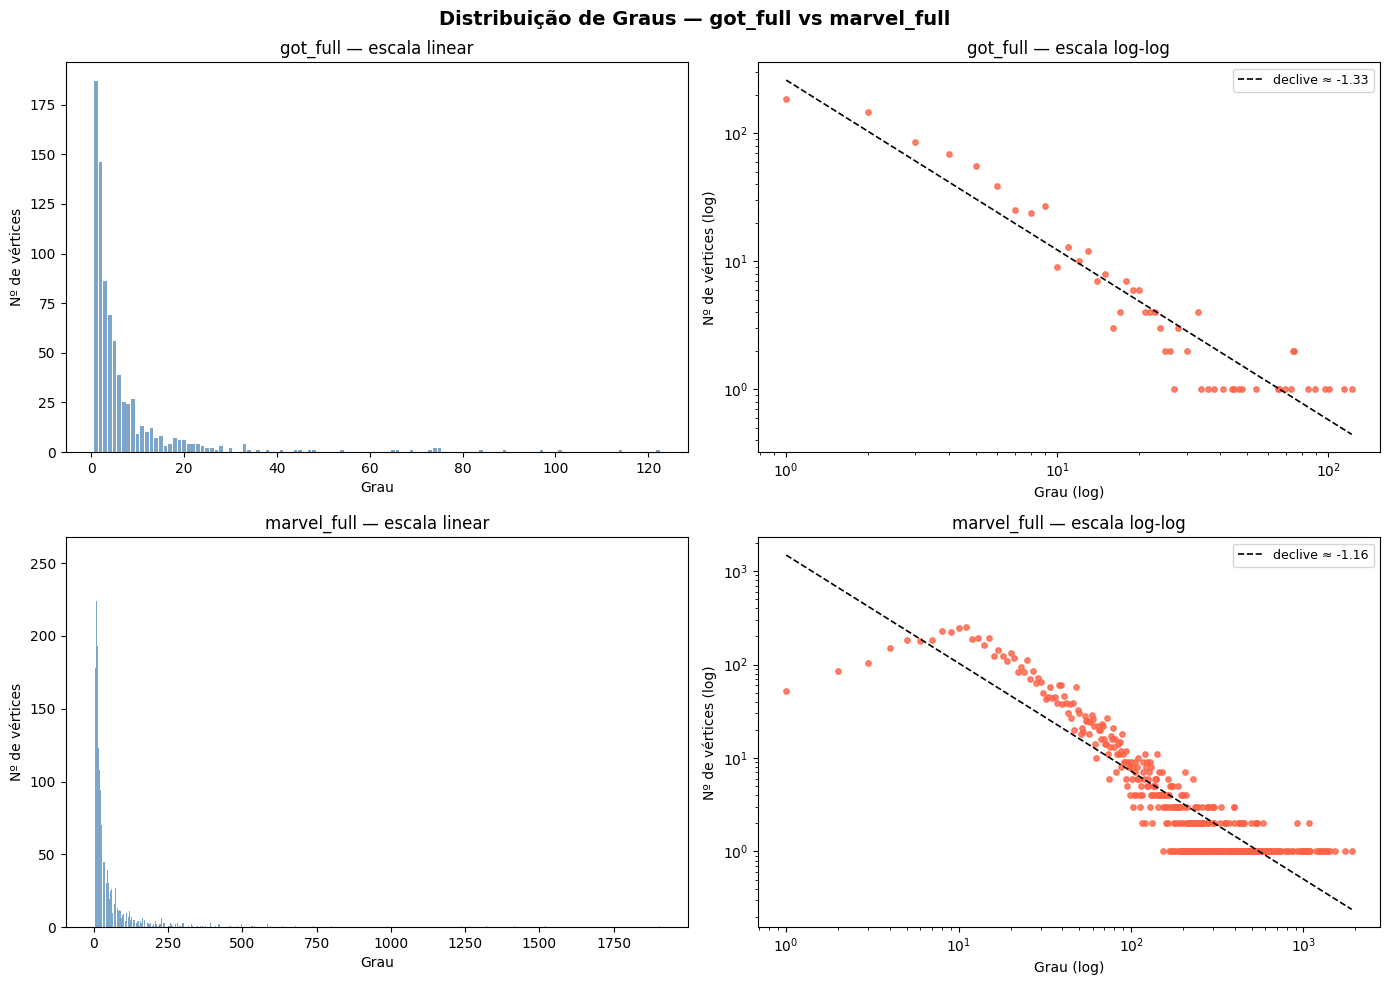

Rank  got_book1                      got_full                      
1     Eddard-Stark           (grau=66 )  Tyrion-Lannister       (grau=122)
2     Robert-Baratheon       (grau=50 )  Jon-Snow               (grau=114)
3     Tyrion-Lannister       (grau=46 )  Jaime-Lannister        (grau=101)
4     Catelyn-Stark          (grau=43 )  Cersei-Lannister       (grau=97 )
5     Jon-Snow               (grau=37 )  Stannis-Baratheon      (grau=89 )
6     Robb-Stark             (grau=35 )  Arya-Stark             (grau=84 )
7     Sansa-Stark            (grau=35 )  Catelyn-Stark          (grau=75 )
8     Bran-Stark             (grau=32 )  Sansa-Stark            (grau=75 )
9     Cersei-Lannister       (grau=30 )  Robb-Stark             (grau=74 )
10    Joffrey-Baratheon      (grau=30 )  Eddard-Stark           (grau=74 )

Personagens do top-10 book1 que se mantêm no top-10 full: ['Eddard-Stark', 'Tyrion-Lannister', 'Catelyn-Stark', 'Jon-Snow', 'Robb-Stark', 'Sansa-Stark', 'Cersei-Lannister']
Personag

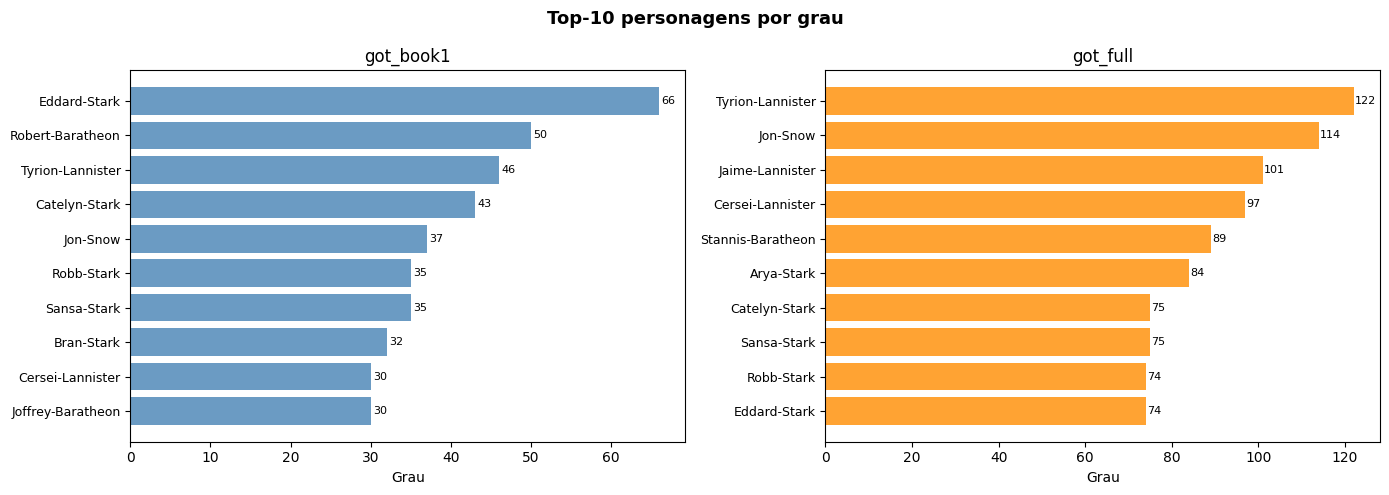

In [9]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# ══════════════════════════════════════════════
#  SECÇÃO 2.3 — Distribuição de Graus e Top-10
# ══════════════════════════════════════════════

# ── Carrega os 4 datasets necessários ──
graph_book1, id2n_book1, n2id_book1 = load_graph_from_csv("got_book1.csv")
graph_full,  id2n_full,  n2id_full  = load_graph_from_csv("got_full.csv")
graph_mfull, id2n_mfull, n2id_mfull = load_graph_from_csv("marvel_full.csv")

analyzer_book1 = CentralityAnalyzer(graph_book1)
analyzer_full  = CentralityAnalyzer(graph_full)
analyzer_mfull = CentralityAnalyzer(graph_mfull)

# ── Calcula distribuições de grau ──
dd_full  = analyzer_full.degree_distribution()   # {grau → nº vértices}
dd_mfull = analyzer_mfull.degree_distribution()

# ────────────────────────────────────────────────────────────
#  HISTOGRAMAS (escala log-log para evidenciar lei de potência)
# ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Distribuição de Graus — got_full vs marvel_full", fontsize=14, fontweight='bold')

datasets_hist = [
    (dd_full,  "got_full",    axes[0][0], axes[0][1]),
    (dd_mfull, "marvel_full", axes[1][0], axes[1][1]),
]

for dd, label, ax_lin, ax_log in datasets_hist:
    degrees = sorted(dd.keys())
    counts  = [dd[d] for d in degrees]

    # Escala linear
    ax_lin.bar(degrees, counts, color='steelblue', alpha=0.7, width=0.8)
    ax_lin.set_title(f"{label} — escala linear")
    ax_lin.set_xlabel("Grau")
    ax_lin.set_ylabel("Nº de vértices")

    # Escala log-log
    ax_log.scatter(degrees, counts, color='tomato', s=15, alpha=0.8)
    ax_log.set_xscale('log')
    ax_log.set_yscale('log')
    ax_log.set_title(f"{label} — escala log-log")
    ax_log.set_xlabel("Grau (log)")
    ax_log.set_ylabel("Nº de vértices (log)")

    # Linha de tendência em log-log (regressão linear sobre logs)
    log_d = np.log10([d for d in degrees if d > 0])
    log_c = np.log10([dd[d] for d in degrees if d > 0])
    if len(log_d) > 1:
        coeffs = np.polyfit(log_d, log_c, 1)
        x_fit  = np.linspace(min(log_d), max(log_d), 100)
        y_fit  = np.polyval(coeffs, x_fit)
        ax_log.plot(10**x_fit, 10**y_fit, 'k--', linewidth=1.2,
                    label=f"declive ≈ {coeffs[0]:.2f}")
        ax_log.legend(fontsize=9)

plt.tight_layout()
plt.show()

# ────────────────────────────────────────────────────────────
#  TOP-10 POR GRAU — got_book1 e got_full
# ────────────────────────────────────────────────────────────
def top10_by_degree(graph, id_to_name):
    """Devolve lista de (nome, grau) ordenada por grau decrescente (top-10)."""
    degrees = []
    for v in graph.vertices():
        vid = v.vertex_id()
        degrees.append((id_to_name[vid], graph.degree(vid)))
    degrees.sort(key=lambda x: x[1], reverse=True)
    return degrees[:10]

top_book1 = top10_by_degree(graph_book1, id2n_book1)
top_full  = top10_by_degree(graph_full,  id2n_full)

# Tabela comparativa
print("=" * 60)
print(f"{'Rank':<5} {'got_book1':<30} {'got_full':<30}")
print("=" * 60)
for i, ((name1, deg1), (name2, deg2)) in enumerate(zip(top_book1, top_full), 1):
    print(f"{i:<5} {name1:<22} (grau={deg1:<3})  {name2:<22} (grau={deg2:<3})")
print("=" * 60)

# Personagens do book1 que mantêm posição no full
names_book1 = [n for n, _ in top_book1]
names_full  = [n for n, _ in top_full]
maintained  = [n for n in names_book1 if n in names_full]
dropped     = [n for n in names_book1 if n not in names_full]
new_entries = [n for n in names_full  if n not in names_book1]

print(f"\nPersonagens do top-10 book1 que se mantêm no top-10 full: {maintained}")
print(f"Personagens que saíram do top-10:                         {dropped}")
print(f"Novas entradas no top-10 full:                            {new_entries}")

# ── Visualização: gráfico de barras lado a lado ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Top-10 personagens por grau", fontsize=13, fontweight='bold')

for ax, top, title, color in [
    (ax1, top_book1, "got_book1", "steelblue"),
    (ax2, top_full,  "got_full",  "darkorange"),
]:
    names  = [n for n, _ in top]
    values = [d for _, d in top]
    bars = ax.barh(range(len(names)), values, color=color, alpha=0.8)
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels(names, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel("Grau")
    ax.set_title(title)
    for bar, val in zip(bars, values):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                str(val), va='center', fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
# ══════════════════════════════════════════════
#  SECÇÃO 2.4 — Diâmetro
# ══════════════════════════════════════════════

def get_diameter_with_path(analyzer, graph, id_to_name):
    lc = analyzer.largest_component()
    
    best_dist    = 0
    best_u_id    = None
    best_v_id    = None
    best_parents = None

    for v in lc.vertices():
        parents, distTo, _, _ = analyzer.bfs(v.vertex_id())

        for u in lc.vertices():
            d = distTo[u.vertex_id()]
            if d > best_dist:
                best_dist    = d
                best_u_id    = v.vertex_id()
                best_v_id    = u.vertex_id()
                best_parents = parents

    # Garante que há sempre um caminho a mostrar
    if best_parents is None or best_u_id is None or best_v_id is None:
        return 0, "N/A", "N/A", []

    path_ids   = reconstruct_path(best_parents, best_u_id, best_v_id)
    path_names = [id_to_name[pid] for pid in path_ids]

    # Fallback: se reconstruct_path devolveu [] por algum motivo, refaz o BFS
    if not path_names:
        parents, _, _, _ = analyzer.bfs(best_u_id)
        path_ids   = reconstruct_path(parents, best_u_id, best_v_id)
        path_names = [id_to_name[pid] for pid in path_ids]

    return best_dist, id_to_name[best_u_id], id_to_name[best_v_id], path_names


# ── Datasets a analisar ──
datasets_24 = [
    ("got_full",    graph_full,  analyzer_full,  id2n_full),
    ("marvel_full", graph_mfull, analyzer_mfull, id2n_mfull),
]

for ds_name, graph, analyzer, id_to_name in datasets_24:
    print("=" * 65)
    print(f"Dataset: {ds_name}  ({graph.order()} vértices, {graph.size()} arestas)")
    print("=" * 65)

    print("A calcular diâmetro...")
    diam, name_u, name_v, path = get_diameter_with_path(analyzer, graph, id_to_name)

    print(f"\n  Diâmetro: {diam}")
    print(f"  Par que realiza a distância máxima:")
    print(f"    '{name_u}'  ↔  '{name_v}'")

    print(f"\n  Caminho ({len(path)} nós, {diam} arestas):")
    # Imprime o caminho por linhas de 5 em 5 para não ficar ilegível
    for i in range(0, len(path), 5):
        chunk = path[i:i+5]
        sep   = " → " if i + 5 < len(path) else ""
        print("    " + " → ".join(chunk) + (" →" if sep else ""))

    print(f"\n  Teoria dos seis graus de separação:")
    if diam <= 6:
        print(f"    → Diâmetro {diam} ≤ 6: a rede respeita a teoria.")
    else:
        print(f"    → Diâmetro {diam} > 6: a rede excede a teoria.")
    print()

# ── Datasets a analisar ──
datasets_24 = [
    ("got_full",    graph_full,  analyzer_full,  id2n_full),
    ("marvel_full", graph_mfull, analyzer_mfull, id2n_mfull),
]

Dataset: got_full  (796 vértices, 2823 arestas)
A calcular diâmetro...

  Diâmetro: 9
  Par que realiza a distância máxima:
    'Lucifer-Long'  ↔  'Gormon-Tyrell'

  Caminho (10 nós, 9 arestas):
    Lucifer-Long → Caggo → Gerris-Drinkwater → Barristan-Selmy → Robert-Baratheon →
    Aemon-Targaryen-(Maester-Aemon) → Alleras → Pate-(novice) → Walgrave → Gormon-Tyrell

  Teoria dos seis graus de separação:
    → Diâmetro 9 > 6: a rede excede a teoria.

Dataset: marvel_full  (6421 vértices, 167112 arestas)
A calcular diâmetro...

  Diâmetro: 5
  Par que realiza a distância máxima:
    '24-HOUR MAN/EMMANUEL'  ↔  '8-BALL/'

  Caminho (6 nós, 5 arestas):
    24-HOUR MAN/EMMANUEL → FROST, CARMILLA → ABRAXAS → ETERNITY/ADAM QADMON → SLEEPWALKER →
    8-BALL/

  Teoria dos seis graus de separação:
    → Diâmetro 5 ≤ 6: a rede respeita a teoria.



Rank  got_book1                           got_full                           
1     Eddard-Stark              (DC=0.3548)   Tyrion-Lannister          (DC=0.1535)
2     Robert-Baratheon          (DC=0.2688)   Jon-Snow                  (DC=0.1434)
3     Tyrion-Lannister          (DC=0.2473)   Jaime-Lannister           (DC=0.1270)
4     Catelyn-Stark             (DC=0.2312)   Cersei-Lannister          (DC=0.1220)
5     Jon-Snow                  (DC=0.1989)   Stannis-Baratheon         (DC=0.1119)
6     Robb-Stark                (DC=0.1882)   Arya-Stark                (DC=0.1057)
7     Sansa-Stark               (DC=0.1882)   Catelyn-Stark             (DC=0.0943)
8     Bran-Stark                (DC=0.1720)   Sansa-Stark               (DC=0.0943)
9     Cersei-Lannister          (DC=0.1613)   Robb-Stark                (DC=0.0931)
10    Joffrey-Baratheon         (DC=0.1613)   Eddard-Stark              (DC=0.0931)

── Comparação top-10 DC vs top-10 por grau (got_book1) ──
  Rankings idênticos? S

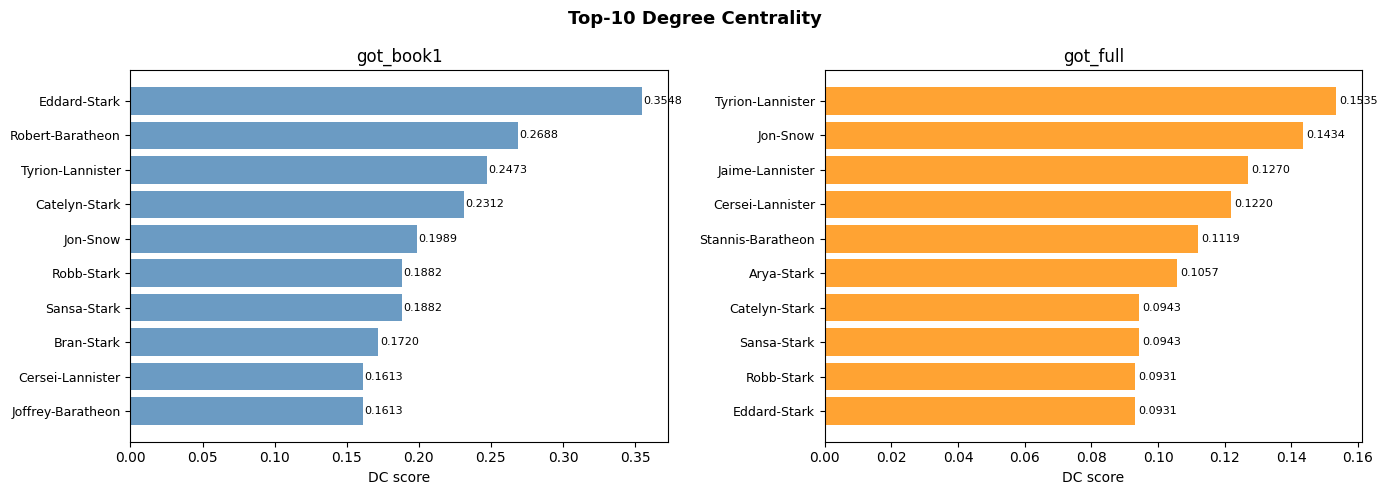

In [10]:
# ══════════════════════════════════════════════
#  SECÇÃO 3.1 — Degree Centrality (DC)
# ══════════════════════════════════════════════

def top10_by_metric(scores, id_to_name):
    """Devolve lista de (nome, score) ordenada por score decrescente (top-10)."""
    ranking = [(id_to_name[vid], score) for vid, score in scores.items()]
    ranking.sort(key=lambda x: x[1], reverse=True)
    return ranking[:10]


# ── Calcula DC para os dois datasets ──
dc_book1 = analyzer_book1.degree_centrality()
dc_full  = analyzer_full.degree_centrality()

top_dc_book1 = top10_by_metric(dc_book1, id2n_book1)
top_dc_full  = top10_by_metric(dc_full,  id2n_full)

# ── Tabela top-10 DC ──
print("=" * 70)
print(f"{'Rank':<5} {'got_book1':<35} {'got_full':<35}")
print("=" * 70)
for i, ((n1, s1), (n2, s2)) in enumerate(zip(top_dc_book1, top_dc_full), 1):
    print(f"{i:<5} {n1:<25} (DC={s1:.4f})   {n2:<25} (DC={s2:.4f})")
print("=" * 70)

# ── Comparação DC vs Grau (Secção 2.3) ──
print("\n── Comparação top-10 DC vs top-10 por grau (got_book1) ──")
names_dc_book1    = [n for n, _ in top_dc_book1]
names_grau_book1  = [n for n, _ in top_book1]   # top_book1 calculado na secção 2.3

iguais = names_dc_book1 == names_grau_book1
print(f"  Rankings idênticos? {'SIM' if iguais else 'NÃO'}")
if not iguais:
    diff = [(i+1, ng, nd) for i, (ng, nd) in enumerate(zip(names_grau_book1, names_dc_book1)) if ng != nd]
    for rank, ng, nd in diff:
        print(f"  Rank {rank}: grau={ng}  |  DC={nd}")

# ── Comparação book1 vs full ──
print("\n── Personagens do top-10 DC book1 que se mantêm no top-10 DC full ──")
names_dc_full = [n for n, _ in top_dc_full]
maintained  = [n for n in names_dc_book1 if n in names_dc_full]
dropped     = [n for n in names_dc_book1 if n not in names_dc_full]
new_entries = [n for n in names_dc_full  if n not in names_dc_book1]

print(f"  Mantêm-se : {maintained}")
print(f"  Saíram    : {dropped}")
print(f"  Entraram  : {new_entries}")

# ── Visualização: gráfico de barras lado a lado ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Top-10 Degree Centrality", fontsize=13, fontweight='bold')

for ax, top, title, color in [
    (ax1, top_dc_book1, "got_book1", "steelblue"),
    (ax2, top_dc_full,  "got_full",  "darkorange"),
]:
    names  = [n for n, _ in top]
    values = [s for _, s in top]
    bars = ax.barh(range(len(names)), values, color=color, alpha=0.8)
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels(names, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel("DC score")
    ax.set_title(title)
    for bar, val in zip(bars, values):
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                f"{val:.4f}", va='center', fontsize=8)

plt.tight_layout()
plt.show()


TOP-10 Closeness Centrality — got_book1

   1. Eddard-Stark                   CC = 0.563636
   2. Robert-Baratheon               CC = 0.545455
   3. Tyrion-Lannister               CC = 0.510989
   4. Catelyn-Stark                  CC = 0.505435
   5. Robb-Stark                     CC = 0.497326
   6. Jon-Snow                       CC = 0.493369
   7. Sansa-Stark                    CC = 0.489474
   8. Bran-Stark                     CC = 0.486911
   9. Cersei-Lannister               CC = 0.484375
  10. Joffrey-Baratheon              CC = 0.480620

  'Eddard-Stark' está na posição #1 do ranking CC.
  → SIM, Eddard-Stark surge no topo do ranking.

Impacto da remoção de Eddard-Stark

  Vértice 'Eddard-Stark' removido com sucesso.


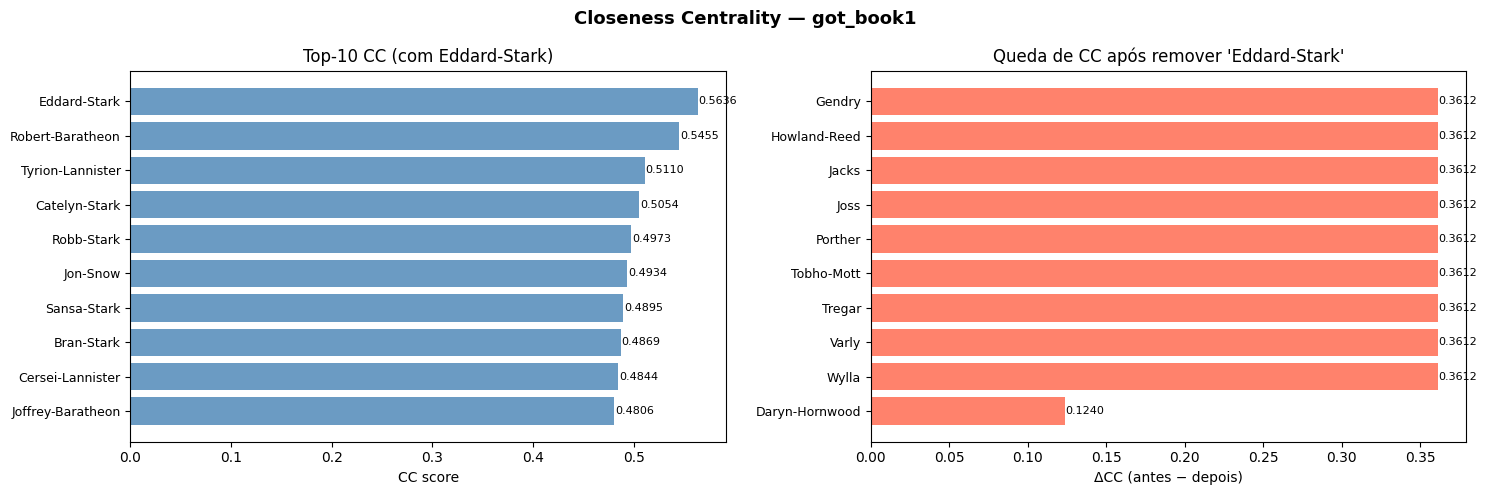

In [11]:
import io
import sys

# ── Utilitário para suprimir prints indesejados ──
class SuppressOutput:
    def __enter__(self):
        self._original = sys.stdout
        sys.stdout = io.StringIO()
        return self
    def __exit__(self, *args):
        sys.stdout = self._original


# ────────────────────────────────────────────────────────────
#  TOP-10 CC — got_book1
# ────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("TOP-10 Closeness Centrality — got_book1")
print("=" * 60)

with SuppressOutput():
    cc_book1 = analyzer_book1.closeness_centrality()

top_cc_book1 = top10_by_metric(cc_book1, id2n_book1)

print()
for i, (name, score) in enumerate(top_cc_book1, 1):
    print(f"  {i:>2}. {name:<30} CC = {score:.6f}")

# Pergunta: Eddard-Stark no topo?
eddard_name = "Eddard-Stark"
cc_ranking  = sorted(cc_book1.items(), key=lambda x: x[1], reverse=True)
eddard_rank = next((i for i, (vid, _) in enumerate(cc_ranking, 1)
                    if id2n_book1[vid] == eddard_name), None)

print(f"\n  '{eddard_name}' está na posição #{eddard_rank} do ranking CC.")
if eddard_rank == 1:
    print("  → SIM, Eddard-Stark surge no topo do ranking.")
else:
    print(f"  → Eddard-Stark não está no topo (posição #{eddard_rank}).")


# ────────────────────────────────────────────────────────────
#  REMOÇÃO DE EDDARD-STARK e recálculo de CC
# ────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("Impacto da remoção de Eddard-Stark")
print("=" * 60)

with SuppressOutput():
    graph_no_eddard, id2n_no_eddard, n2id_no_eddard = load_graph_from_csv("got_book1.csv")
    eddard_id_new = n2id_no_eddard.get(eddard_name)
    if eddard_id_new is not None:
        graph_no_eddard.remove_vertex(eddard_id_new)
    analyzer_no_eddard = CentralityAnalyzer(graph_no_eddard)
    cc_no_eddard = analyzer_no_eddard.closeness_centrality()

print(f"\n  Vértice '{eddard_name}' removido com sucesso.")

# Calcula ΔCC = CC_antes - CC_depois
delta_cc = {}
for vid, name in id2n_book1.items():
    if name == eddard_name:
        continue
    new_id = n2id_no_eddard.get(name)
    if new_id is None:
        continue
    cc_antes  = cc_book1.get(vid, 0)
    cc_depois = cc_no_eddard.get(new_id, 0)
    delta_cc[name] = (cc_antes, cc_depois, cc_antes - cc_depois)

top_delta = sorted(
    ((n, ca, cd, d) for n, (ca, cd, d) in delta_cc.items() if d > 0),
    key=lambda x: x[3], reverse=True
)[:10]

cc_no_eddard_by_name = {
    name: cc_no_eddard[n2id_no_eddard[name]]
    for name in id2n_book1.values()
    if name != eddard_name and name in n2id_no_eddard
}
top_cc_no_eddard = sorted(cc_no_eddard_by_name.items(), key=lambda x: x[1], reverse=True)[:10]


# ────────────────────────────────────────────────────────────
#  VISUALIZAÇÃO
# ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Closeness Centrality — got_book1", fontsize=13, fontweight='bold')

# Gráfico 1: top-10 CC com Eddard
names_cc  = [n for n, _ in top_cc_book1]
values_cc = [s for _, s in top_cc_book1]
bars1 = axes[0].barh(range(len(names_cc)), values_cc, color='steelblue', alpha=0.8)
axes[0].set_yticks(range(len(names_cc)))
axes[0].set_yticklabels(names_cc, fontsize=9)
axes[0].invert_yaxis()
axes[0].set_xlabel("CC score")
axes[0].set_title("Top-10 CC (com Eddard-Stark)")
for bar, val in zip(bars1, values_cc):
    axes[0].text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                 f"{val:.4f}", va='center', fontsize=8)

# Gráfico 2: ΔCC top-10 mais afetados
names_d  = [n for n, _ in [(n, d) for n, _, _, d in top_delta]]
values_d = [d for _, _, _, d in top_delta]
bars2 = axes[1].barh(range(len(names_d)), values_d, color='tomato', alpha=0.8)
axes[1].set_yticks(range(len(names_d)))
axes[1].set_yticklabels(names_d, fontsize=9)
axes[1].invert_yaxis()
axes[1].set_xlabel("ΔCC (antes − depois)")
axes[1].set_title(f"Queda de CC após remover '{eddard_name}'")
for bar, val in zip(bars2, values_d):
    axes[1].text(bar.get_width() + 0.0001, bar.get_y() + bar.get_height()/2,
                 f"{val:.4f}", va='center', fontsize=8)

plt.tight_layout()
plt.show()

VALIDAÇÃO MANUAL — grafo de 4 vértices

  EC calculada (convergiu em 36 iterações):
    vértice 0: EC = 0.854638
    vértice 1: EC = 1.000000
    vértice 2: EC = 0.854638
    vértice 3: EC = 0.460811

  Verificação qualitativa:
    vértice 1 tem EC mais alto? ✓ SIM
    vértice 3 tem EC mais baixo? ✓ SIM
    vértices 0 e 2 têm EC igual? ✓ SIM

TOP-10 Eigenvector Centrality — got_book1

  (convergiu em 16 iterações)

   1. Eddard-Stark                   EC = 1.000000
   2. Robert-Baratheon               EC = 0.909174
   3. Sansa-Stark                    EC = 0.781188
   4. Tyrion-Lannister               EC = 0.759769
   5. Joffrey-Baratheon              EC = 0.744764
   6. Cersei-Lannister               EC = 0.730187
   7. Catelyn-Stark                  EC = 0.717078
   8. Petyr-Baelish                  EC = 0.679686
   9. Jaime-Lannister                EC = 0.657735
  10. Bran-Stark                     EC = 0.653726

Comparação EC vs DC — got_book1

  Rank  Top-10 EC                    

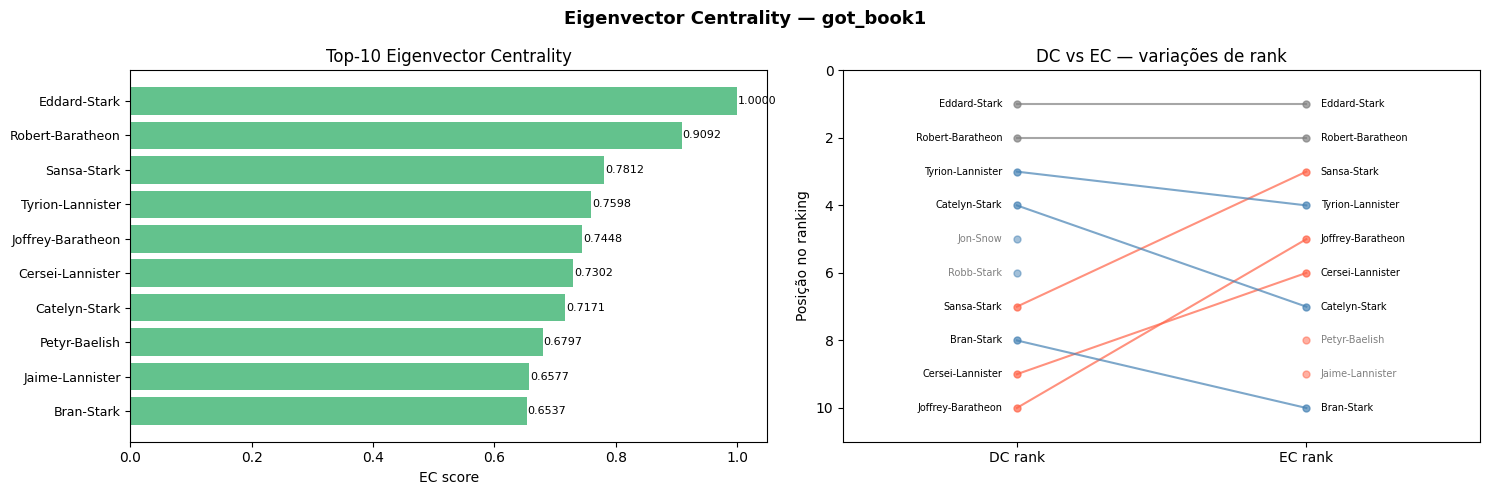

In [13]:
# ══════════════════════════════════════════════
#  SECÇÃO 3.3 — Eigenvector Centrality (EC)
# ══════════════════════════════════════════════

# Monkey-patch para silenciar o insert_edge de uma vez por todas
_original_insert_edge = Graph.insert_edge

def _silent_insert_edge(self, u_id, v_id, weight=0):
    if not self.has_vertex(u_id):
        self.insert_vertex(u_id)
    if not self.has_vertex(v_id):
        self.insert_vertex(v_id)
    if not self.has_edge(u_id, v_id):
        self._m += 1
    vertex_u = self._vertices[u_id]
    vertex_v = self._vertices[v_id]
    e = Edge(vertex_u, vertex_v, weight)
    self._adjancencies[vertex_u][vertex_v] = e
    self._adjancencies[vertex_v][vertex_u] = e

Graph.insert_edge = _silent_insert_edge

# ────────────────────────────────────────────────────────────
#  VALIDAÇÃO MANUAL — grafo pequeno construído à mão
# ────────────────────────────────────────────────────────────
print("=" * 60)
print("VALIDAÇÃO MANUAL — grafo de 4 vértices")
print("=" * 60)

g_ec_test = Graph()
for e in [(0,1,1),(0,2,1),(1,2,1),(1,3,1)]:
    g_ec_test.insert_edge(*e)

analyzer_ec_test = CentralityAnalyzer(g_ec_test)
ec_test, k_test  = analyzer_ec_test.eigenvector_centrality()

print(f"\n  EC calculada (convergiu em {k_test} iterações):")
for vid in sorted(ec_test):
    print(f"    vértice {vid}: EC = {ec_test[vid]:.6f}")

print(f"\n  Verificação qualitativa:")
print(f"    vértice 1 tem EC mais alto? {'✓ SIM' if ec_test[1] >= max(ec_test.values()) - 1e-9 else '✗ NÃO'}")
print(f"    vértice 3 tem EC mais baixo? {'✓ SIM' if ec_test[3] <= min(ec_test.values()) + 1e-9 else '✗ NÃO'}")
print(f"    vértices 0 e 2 têm EC igual? {'✓ SIM' if abs(ec_test[0] - ec_test[2]) < 1e-6 else '✗ NÃO'}")


# ────────────────────────────────────────────────────────────
#  TOP-10 EC — got_book1
# ────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("TOP-10 Eigenvector Centrality — got_book1")
print("=" * 60)

ec_book1, k_book1 = analyzer_book1.eigenvector_centrality()
top_ec_book1      = top10_by_metric(ec_book1, id2n_book1)

print(f"\n  (convergiu em {k_book1} iterações)\n")
for i, (name, score) in enumerate(top_ec_book1, 1):
    print(f"  {i:>2}. {name:<30} EC = {score:.6f}")


# ────────────────────────────────────────────────────────────
#  COMPARAÇÃO EC vs DC
# ────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("Comparação EC vs DC — got_book1")
print("=" * 60)

names_ec = [n for n, _ in top_ec_book1]
names_dc = [n for n, _ in top_dc_book1]

print(f"\n  {'Rank':<5} {'Top-10 EC':<30} {'Top-10 DC':<30}")
print("  " + "-" * 65)
for i, (ne, nd) in enumerate(zip(names_ec, names_dc), 1):
    marker = "  ←" if ne != nd else ""
    print(f"  {i:<5} {ne:<30} {nd:<30}{marker}")

only_ec = [n for n in names_ec if n not in names_dc]
only_dc = [n for n in names_dc if n not in names_ec]

print(f"\n  Apenas no top-10 EC (não estão no top-10 DC): {only_ec}")
print(f"  Apenas no top-10 DC (não estão no top-10 EC): {only_dc}")

print(f"\n  Variações de posição (EC rank − DC rank):")
for name in names_ec:
    rank_ec = names_ec.index(name) + 1
    if name in names_dc:
        rank_dc = names_dc.index(name) + 1
        delta   = rank_dc - rank_ec
        if delta != 0:
            direcao = "subiu ↑" if delta > 0 else "desceu ↓"
            print(f"    {name:<30} DC=#{rank_dc}  EC=#{rank_ec}  Δ={delta:+d} ({direcao})")


# ────────────────────────────────────────────────────────────
#  VISUALIZAÇÃO
# ────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Eigenvector Centrality — got_book1", fontsize=13, fontweight='bold')

names_e  = [n for n, _ in top_ec_book1]
values_e = [s for _, s in top_ec_book1]
bars1 = ax1.barh(range(len(names_e)), values_e, color='mediumseagreen', alpha=0.8)
ax1.set_yticks(range(len(names_e)))
ax1.set_yticklabels(names_e, fontsize=9)
ax1.invert_yaxis()
ax1.set_xlabel("EC score")
ax1.set_title("Top-10 Eigenvector Centrality")
for bar, val in zip(bars1, values_e):
    ax1.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
             f"{val:.4f}", va='center', fontsize=8)

all_names = list(dict.fromkeys(names_ec + names_dc))
ec_ranks  = {n: names_ec.index(n) + 1 for n in names_ec}
dc_ranks  = {n: names_dc.index(n) + 1 for n in names_dc}

for name in all_names:
    r_ec = ec_ranks.get(name)
    r_dc = dc_ranks.get(name)
    if r_ec and r_dc:
        color = 'tomato' if r_ec < r_dc else ('steelblue' if r_ec > r_dc else 'gray')
        ax2.plot([0, 1], [r_dc, r_ec], '-o', color=color, alpha=0.7, markersize=5)
        ax2.text(-0.05, r_dc, name, ha='right', va='center', fontsize=7)
        ax2.text( 1.05, r_ec, name, ha='left',  va='center', fontsize=7)
    elif r_dc:
        ax2.plot([0], [r_dc], 'o', color='steelblue', alpha=0.5, markersize=5)
        ax2.text(-0.05, r_dc, name, ha='right', va='center', fontsize=7, alpha=0.5)
    elif r_ec:
        ax2.plot([1], [r_ec], 'o', color='tomato', alpha=0.5, markersize=5)
        ax2.text(1.05, r_ec, name, ha='left', va='center', fontsize=7, alpha=0.5)

ax2.set_xlim(-0.6, 1.6)
ax2.set_ylim(11, 0)
ax2.set_xticks([0, 1])
ax2.set_xticklabels(['DC rank', 'EC rank'])
ax2.set_ylabel("Posição no ranking")
ax2.set_title("DC vs EC — variações de rank")
ax2.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

VALIDAÇÃO MANUAL — grafo de 6 vértices

  Grafo:  0 ── 1 ── 2
               |
          4 ── 3 ── 5

  BC(1) esperada (normalizada) = 14/20 = 0.700000
  BC(3) esperada (normalizada) = 14/20 = 0.700000
  BC(0) esperada = 0.0  (folha)
  BC(2) esperada = 0.0  (folha)
  BC(4) esperada = 0.0  (folha)
  BC(5) esperada = 0.0  (folha)

  BC calculada:
    vértice 0: BC = 0.000000
    vértice 1: BC = 1.400000
    vértice 2: BC = 0.000000
    vértice 3: BC = 1.400000
    vértice 4: BC = 0.000000
    vértice 5: BC = 0.000000

  Verificação:
    BC(1) ≈ 0.700000? ✗ NÃO  (obtido 1.400000)
    BC(3) ≈ 0.700000? ✗ NÃO  (obtido 1.400000)
    BC(0) ≈ 0.000000? ✓ SIM

TOP-10 Betweenness Centrality — got_full
  (a calcular — pode demorar alguns segundos...)

   1. Jon-Snow                       BC = 0.384239
   2. Tyrion-Lannister               BC = 0.324382
   3. Daenerys-Targaryen             BC = 0.236836
   4. Theon-Greyjoy                  BC = 0.222567
   5. Stannis-Baratheon              BC = 0.2

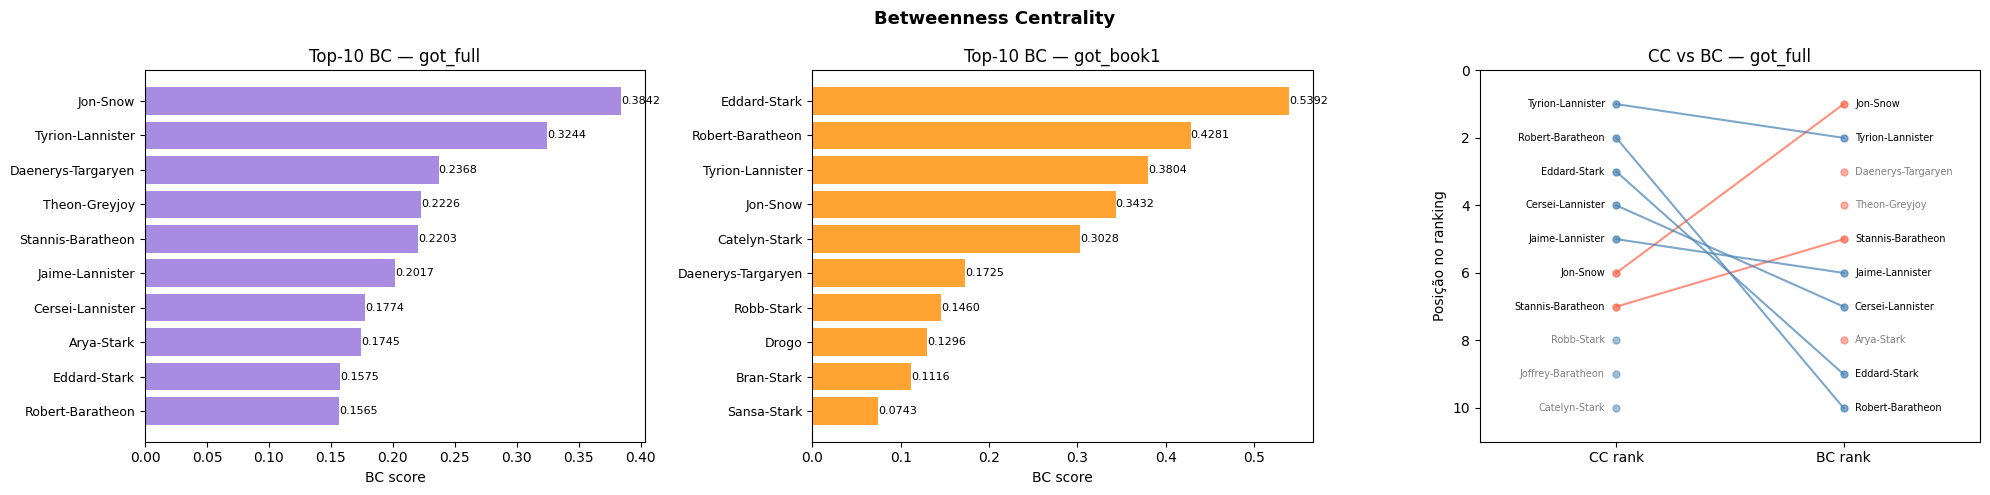

In [14]:
# ══════════════════════════════════════════════
#  SECÇÃO 3.4 — Betweenness Centrality (BC)
# ══════════════════════════════════════════════

# ────────────────────────────────────────────────────────────
#  VALIDAÇÃO MANUAL — grafo pequeno construído à mão
#
#  Grafo de exemplo (6 vértices, não orientado):
#
#       0 ── 1 ── 2
#            |
#       4 ── 3 ── 5
#
#  Arestas: (0,1), (1,2), (1,3), (3,4), (3,5)
#
#  BC(1): vértice 1 é ponte entre {0} e {2,3,4,5}
#    Pares que passam por 1:
#      (0,2): 1 caminho, passa por 1 → contribui 1
#      (0,3): 1 caminho, passa por 1 → contribui 1
#      (0,4): 1 caminho, passa por 1 → contribui 1
#      (0,5): 1 caminho, passa por 1 → contribui 1
#      (2,3): 1 caminho, passa por 1 → contribui 1
#      (2,4): 1 caminho, passa por 1 → contribui 1
#      (2,5): 1 caminho, passa por 1 → contribui 1
#    Total pares = C(6,2) = 15
#    BC(1) = 7 / (5*4/2) * 2 ... formula normalizada
#    BC(1) não normalizada = 7
#    BC(1) normalizada = 2*7 / ((6-1)*(6-2)) = 14/20 = 0.7
#
#  BC(3): vértice 3 é ponte entre {4,5} e {0,1,2}
#    Pares que passam por 3:
#      (4,5): passa por 3 → contribui 1
#      (0,4),(0,5),(1,4),(1,5),(2,4),(2,5) → contribui 6
#    BC(3) não normalizada = 7
#    BC(3) normalizada = 14/20 = 0.7
# ────────────────────────────────────────────────────────────
print("=" * 60)
print("VALIDAÇÃO MANUAL — grafo de 6 vértices")
print("=" * 60)
print("""
  Grafo:  0 ── 1 ── 2
               |
          4 ── 3 ── 5

  BC(1) esperada (normalizada) = 14/20 = 0.700000
  BC(3) esperada (normalizada) = 14/20 = 0.700000
  BC(0) esperada = 0.0  (folha)
  BC(2) esperada = 0.0  (folha)
  BC(4) esperada = 0.0  (folha)
  BC(5) esperada = 0.0  (folha)
""")

g_bc_test = Graph()
for e in [(0,1,1),(1,2,1),(1,3,1),(3,4,1),(3,5,1)]:
    g_bc_test.insert_edge(*e)

analyzer_bc_test = CentralityAnalyzer(g_bc_test)
bc_test = analyzer_bc_test.betweenness_centrality()

print("  BC calculada:")
for vid in sorted(bc_test):
    print(f"    vértice {vid}: BC = {bc_test[vid]:.6f}")

print(f"\n  Verificação:")
print(f"    BC(1) ≈ 0.700000? {'✓ SIM' if abs(bc_test[1] - 0.7) < 1e-6 else f'✗ NÃO  (obtido {bc_test[1]:.6f})'}")
print(f"    BC(3) ≈ 0.700000? {'✓ SIM' if abs(bc_test[3] - 0.7) < 1e-6 else f'✗ NÃO  (obtido {bc_test[3]:.6f})'}")
print(f"    BC(0) ≈ 0.000000? {'✓ SIM' if abs(bc_test[0]) < 1e-6 else f'✗ NÃO  (obtido {bc_test[0]:.6f})'}")


# ────────────────────────────────────────────────────────────
#  TOP-10 BC — got_full
# ────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("TOP-10 Betweenness Centrality — got_full")
print("=" * 60)
print("  (a calcular — pode demorar alguns segundos...)")

bc_full  = analyzer_full.betweenness_centrality()
top_bc_full = top10_by_metric(bc_full, id2n_full)

print()
for i, (name, score) in enumerate(top_bc_full, 1):
    print(f"  {i:>2}. {name:<30} BC = {score:.6f}")


# ────────────────────────────────────────────────────────────
#  COMPARAÇÃO BC vs CC — got_full
# ────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("Comparação BC vs CC — got_full")
print("=" * 60)

# CC para got_full
cc_full     = analyzer_full.closeness_centrality()
top_cc_full = top10_by_metric(cc_full, id2n_full)

names_bc_full = [n for n, _ in top_bc_full]
names_cc_full = [n for n, _ in top_cc_full]

print(f"\n  {'Rank':<5} {'Top-10 BC':<30} {'Top-10 CC':<30}")
print("  " + "-" * 65)
for i, (nb, nc) in enumerate(zip(names_bc_full, names_cc_full), 1):
    marker = "  ←" if nb != nc else ""
    print(f"  {i:<5} {nb:<30} {nc:<30}{marker}")

only_bc = [n for n in names_bc_full if n not in names_cc_full]
only_cc = [n for n in names_cc_full if n not in names_bc_full]

print(f"\n  Apenas no top-10 BC (não estão no top-10 CC): {only_bc}")
print(f"  Apenas no top-10 CC (não estão no top-10 BC): {only_cc}")

print(f"\n  Variações de posição:")
for name in names_bc_full:
    rank_bc = names_bc_full.index(name) + 1
    if name in names_cc_full:
        rank_cc = names_cc_full.index(name) + 1
        delta   = rank_cc - rank_bc
        if abs(delta) >= 2:
            direcao = "subiu ↑" if delta > 0 else "desceu ↓"
            print(f"    {name:<30} CC=#{rank_cc}  BC=#{rank_bc}  Δ={delta:+d} ({direcao})")


# ────────────────────────────────────────────────────────────
#  TOP-10 BC — got_book1
# ────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("TOP-10 Betweenness Centrality — got_book1")
print("=" * 60)

bc_book1     = analyzer_book1.betweenness_centrality()
top_bc_book1 = top10_by_metric(bc_book1, id2n_book1)

print()
for i, (name, score) in enumerate(top_bc_book1, 1):
    print(f"  {i:>2}. {name:<30} BC = {score:.6f}")

# Comparação book1 vs full
print("\n" + "=" * 60)
print("Personagens do top-10 BC book1 que se mantêm no top-10 BC full")
print("=" * 60)

names_bc_book1 = [n for n, _ in top_bc_book1]
maintained  = [n for n in names_bc_book1 if n in names_bc_full]
dropped     = [n for n in names_bc_book1 if n not in names_bc_full]
new_entries = [n for n in names_bc_full  if n not in names_bc_book1]

print(f"\n  Mantêm-se : {maintained}")
print(f"  Saíram    : {dropped}")
print(f"  Entraram  : {new_entries}")

print(f"\n  Variações de rank (book1 → full):")
for name in names_bc_book1:
    rank_b1 = names_bc_book1.index(name) + 1
    if name in names_bc_full:
        rank_fu = names_bc_full.index(name) + 1
        delta   = rank_b1 - rank_fu
        direcao = "subiu ↑" if delta > 0 else ("desceu ↓" if delta < 0 else "manteve →")
        print(f"    {name:<30} book1=#{rank_b1}  full=#{rank_fu}  Δ={delta:+d} ({direcao})")
    else:
        print(f"    {name:<30} book1=#{rank_b1}  full= fora do top-10")


# ────────────────────────────────────────────────────────────
#  VISUALIZAÇÃO
# ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle("Betweenness Centrality", fontsize=13, fontweight='bold')

# Gráfico 1: top-10 BC got_full
names_bf  = [n for n, _ in top_bc_full]
values_bf = [s for _, s in top_bc_full]
bars1 = axes[0].barh(range(len(names_bf)), values_bf, color='mediumpurple', alpha=0.8)
axes[0].set_yticks(range(len(names_bf)))
axes[0].set_yticklabels(names_bf, fontsize=9)
axes[0].invert_yaxis()
axes[0].set_xlabel("BC score")
axes[0].set_title("Top-10 BC — got_full")
for bar, val in zip(bars1, values_bf):
    axes[0].text(bar.get_width() + 0.0001, bar.get_y() + bar.get_height()/2,
                 f"{val:.4f}", va='center', fontsize=8)

# Gráfico 2: top-10 BC got_book1
names_bb  = [n for n, _ in top_bc_book1]
values_bb = [s for _, s in top_bc_book1]
bars2 = axes[1].barh(range(len(names_bb)), values_bb, color='darkorange', alpha=0.8)
axes[1].set_yticks(range(len(names_bb)))
axes[1].set_yticklabels(names_bb, fontsize=9)
axes[1].invert_yaxis()
axes[1].set_xlabel("BC score")
axes[1].set_title("Top-10 BC — got_book1")
for bar, val in zip(bars2, values_bb):
    axes[1].text(bar.get_width() + 0.0001, bar.get_y() + bar.get_height()/2,
                 f"{val:.4f}", va='center', fontsize=8)

# Gráfico 3: bump chart BC vs CC got_full
all_names_cmp = list(dict.fromkeys(names_bc_full + names_cc_full))
bc_ranks_cmp  = {n: names_bc_full.index(n) + 1 for n in names_bc_full}
cc_ranks_cmp  = {n: names_cc_full.index(n) + 1 for n in names_cc_full}

for name in all_names_cmp:
    r_bc = bc_ranks_cmp.get(name)
    r_cc = cc_ranks_cmp.get(name)
    if r_bc and r_cc:
        color = 'tomato' if r_bc < r_cc else ('steelblue' if r_bc > r_cc else 'gray')
        axes[2].plot([0, 1], [r_cc, r_bc], '-o', color=color, alpha=0.7, markersize=5)
        axes[2].text(-0.05, r_cc, name, ha='right', va='center', fontsize=7)
        axes[2].text( 1.05, r_bc, name, ha='left',  va='center', fontsize=7)
    elif r_cc:
        axes[2].plot([0], [r_cc], 'o', color='steelblue', alpha=0.5, markersize=5)
        axes[2].text(-0.05, r_cc, name, ha='right', va='center', fontsize=7, alpha=0.5)
    elif r_bc:
        axes[2].plot([1], [r_bc], 'o', color='tomato', alpha=0.5, markersize=5)
        axes[2].text(1.05, r_bc, name, ha='left', va='center', fontsize=7, alpha=0.5)

axes[2].set_xlim(-0.6, 1.6)
axes[2].set_ylim(11, 0)
axes[2].set_xticks([0, 1])
axes[2].set_xticklabels(['CC rank', 'BC rank'])
axes[2].set_ylabel("Posição no ranking")
axes[2].set_title("CC vs BC — got_full")
axes[2].yaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

A carregar datasets...
Datasets carregados.

  Dataset              n        m      n+m
  ------------------------------------------
  got_book1          187      684      871
  got_full           796     2823     3619
  marvel_small       327     9891    10218
  marvel_full       6421   167112   173533

A medir got_book1 (5 repetições)...
  DC... 0.0000s
  EC... 0.0055s
  CC... 0.0645s
  BC... 0.0732s

A medir got_full (5 repetições)...
  DC... 0.0001s
  EC... 0.0349s
  CC... 1.2651s
  BC... 1.4360s

A medir marvel_small (5 repetições)...
  DC... 0.0001s
  EC... 0.0593s
  CC... 1.4298s
  BC... 1.5157s

A medir marvel_full (1 repetições)...
  DC... 0.0011s
  EC... 1.2848s
  CC... 531.9984s
  BC... (a calcular — pode demorar) 573.3877s

Tempos de execução (segundos)

  Dataset                 DC         EC         CC         BC
  -------------------------------------------------------
  got_book1           0.0000     0.0055     0.0645     0.0732
  got_full            0.0001     0.0349  

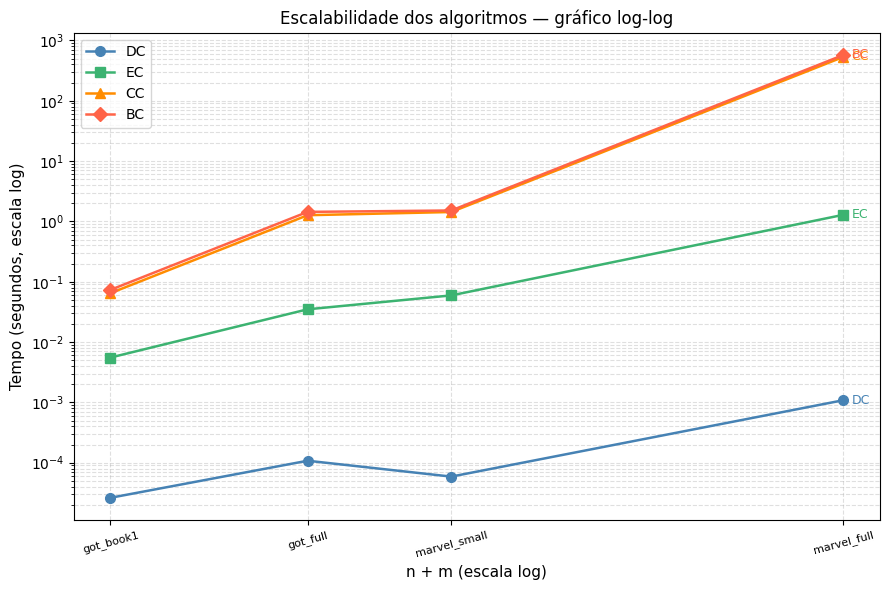

In [15]:
# ══════════════════════════════════════════════
#  SECÇÃO 4.1 — Escalabilidade dos algoritmos
# ══════════════════════════════════════════════

import time
import statistics
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ── Carrega os 4 datasets ──
print("A carregar datasets...")

with SuppressOutput():
    g_book1,  id2n_book1,  n2id_book1  = load_graph_from_csv("got_book1.csv")
    g_full,   id2n_full,   n2id_full   = load_graph_from_csv("got_full.csv")
    g_msmall, id2n_msmall, n2id_msmall = load_graph_from_csv("marvel_small.csv")
    g_mfull,  id2n_mfull,  n2id_mfull  = load_graph_from_csv("marvel_full.csv")

datasets = [
    ("got_book1",    g_book1,  5),
    ("got_full",     g_full,   5),
    ("marvel_small", g_msmall, 5),
    ("marvel_full",  g_mfull,  1),   # só 1 medição
]

print("Datasets carregados.\n")
print(f"  {'Dataset':<15} {'n':>6} {'m':>8} {'n+m':>8}")
print("  " + "-" * 42)
for name, g, _ in datasets:
    print(f"  {name:<15} {g.order():>6} {g.size():>8} {g.order()+g.size():>8}")


# ── Função de medição ──
def measure(func, reps):
    times = []
    for _ in range(reps):
        t0 = time.perf_counter()
        func()
        times.append(time.perf_counter() - t0)
    return statistics.median(times) if len(times) > 1 else times[0]


# ── Medições ──
results = {}   # {dataset_name: {metric: time}}

for ds_name, graph, reps in datasets:
    print(f"\nA medir {ds_name} ({reps} repetições)...")
    az = CentralityAnalyzer(graph)

    # pré-aquece largest_component (usado por EC)
    with SuppressOutput():
        az.largest_component()

    times = {}

    print(f"  DC...", end=" ", flush=True)
    times["DC"] = measure(lambda: az.degree_centrality(), reps)
    print(f"{times['DC']:.4f}s")

    print(f"  EC...", end=" ", flush=True)
    times["EC"] = measure(lambda: az.eigenvector_centrality(), reps)
    print(f"{times['EC']:.4f}s")

    print(f"  CC...", end=" ", flush=True)
    times["CC"] = measure(lambda: az.closeness_centrality(), reps)
    print(f"{times['CC']:.4f}s")

    if ds_name != "marvel_full":
        print(f"  BC...", end=" ", flush=True)
        times["BC"] = measure(lambda: az.betweenness_centrality(), reps)
        print(f"{times['BC']:.4f}s")
    else:
        print(f"  BC... (a calcular — pode demorar)", end=" ", flush=True)
        t0 = time.perf_counter()
        with SuppressOutput():
            az.betweenness_centrality()
        times["BC"] = time.perf_counter() - t0
        print(f"{times['BC']:.4f}s")

    results[ds_name] = times


# ── Tabela de resultados ──
print("\n" + "=" * 60)
print("Tempos de execução (segundos)")
print("=" * 60)
print(f"\n  {'Dataset':<15} {'DC':>10} {'EC':>10} {'CC':>10} {'BC':>10}")
print("  " + "-" * 55)
for ds_name, _, _ in datasets:
    t = results[ds_name]
    print(f"  {ds_name:<15} {t['DC']:>10.4f} {t['EC']:>10.4f} {t['CC']:>10.4f} {t['BC']:>10.4f}")


# ── Gráfico log-log ──
fig, ax = plt.subplots(figsize=(9, 6))

metrics = ["DC", "EC", "CC", "BC"]
colors  = {"DC": "steelblue", "EC": "mediumseagreen", "CC": "darkorange", "BC": "tomato"}
markers = {"DC": "o", "EC": "s", "CC": "^", "BC": "D"}

x_vals = {ds_name: g.order() + g.size() for ds_name, g, _ in datasets}

for metric in metrics:
    xs = []
    ys = []
    for ds_name, _, _ in datasets:
        xs.append(x_vals[ds_name])
        ys.append(results[ds_name][metric])
    ax.plot(xs, ys,
            color=colors[metric],
            marker=markers[metric],
            linewidth=1.8,
            markersize=7,
            label=metric)
    # etiqueta no último ponto
    ax.annotate(metric, (xs[-1], ys[-1]),
                textcoords="offset points", xytext=(6, 0),
                color=colors[metric], fontsize=9, va='center')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel("n + m (escala log)", fontsize=11)
ax.set_ylabel("Tempo (segundos, escala log)", fontsize=11)
ax.set_title("Escalabilidade dos algoritmos — gráfico log-log", fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, which='both', linestyle='--', alpha=0.4)

# etiquetas dos datasets no eixo x
ds_labels = [ds_name for ds_name, _, _ in datasets]
ds_xs     = [x_vals[ds_name] for ds_name, _, _ in datasets]
ax.set_xticks(ds_xs)
ax.set_xticklabels(ds_labels, rotation=15, fontsize=8)
ax.xaxis.set_minor_locator(ticker.NullLocator())

plt.tight_layout()
plt.show()

Razão TBC / TCC por dataset

  Dataset            TCC (s)    TBC (s)    TBC/TCC
  --------------------------------------------------
  got_book1           0.0645     0.0732     1.1355
  got_full            1.2651     1.4360     1.1351
  marvel_small        1.4298     1.5157     1.0600
  marvel_full       531.9984   573.3877     1.0778


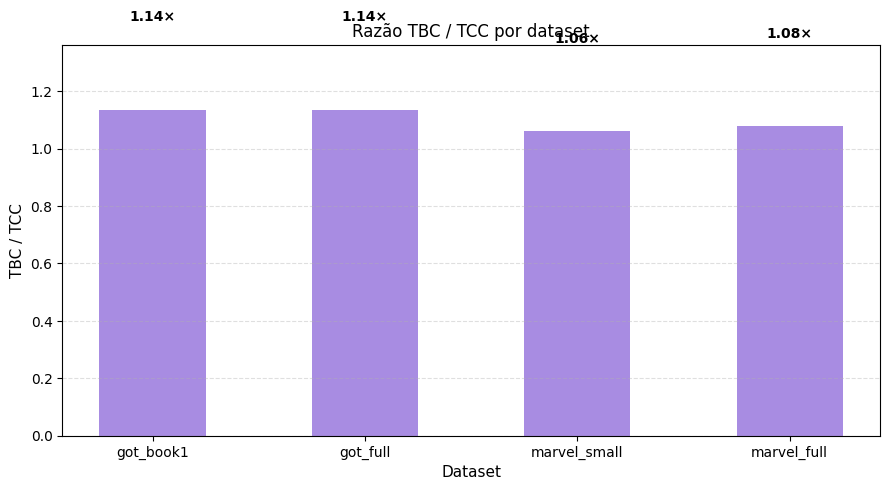

In [16]:
# ══════════════════════════════════════════════
#  SECÇÃO 4.2 — Comparação empírica CC vs BC
# ══════════════════════════════════════════════

# ── Calcula razão TBC/TCC para cada dataset ──
print("=" * 60)
print("Razão TBC / TCC por dataset")
print("=" * 60)

print(f"\n  {'Dataset':<15} {'TCC (s)':>10} {'TBC (s)':>10} {'TBC/TCC':>10}")
print("  " + "-" * 50)

ds_names = []
ratios   = []

for ds_name, _, _ in datasets:
    t_cc = results[ds_name]["CC"]
    t_bc = results[ds_name]["BC"]
    ratio = t_bc / t_cc
    ds_names.append(ds_name)
    ratios.append(ratio)
    print(f"  {ds_name:<15} {t_cc:>10.4f} {t_bc:>10.4f} {ratio:>10.4f}")


# ── Gráfico de barras ──
fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(ds_names, ratios, color='mediumpurple', alpha=0.8, width=0.5)

# Valor em cima de cada barra
for bar, ratio in zip(bars, ratios):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            f"{ratio:.2f}×",
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel("Dataset", fontsize=11)
ax.set_ylabel("TBC / TCC", fontsize=11)
ax.set_title("Razão TBC / TCC por dataset", fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.set_ylim(0, max(ratios) * 1.2)

plt.tight_layout()
plt.show()

In [17]:
for ds_name, graph, _ in datasets:
    az = CentralityAnalyzer(graph)
    with SuppressOutput():
        _, k = az.eigenvector_centrality()
    print(f"  {ds_name:<15} k = {k}")
    

  got_book1       k = 16
  got_full        k = 23
  marvel_small    k = 14
  marvel_full     k = 15


Verificação TCC/TEC ≈ n/k

  Dataset              n    k      n/k    TCC/TEC
  --------------------------------------------------
  got_book1          187   16    11.69      11.73
  got_full           796   23    34.61      36.25
  marvel_small       327   14    23.36      24.11
  marvel_full       6421   15   428.07     414.07


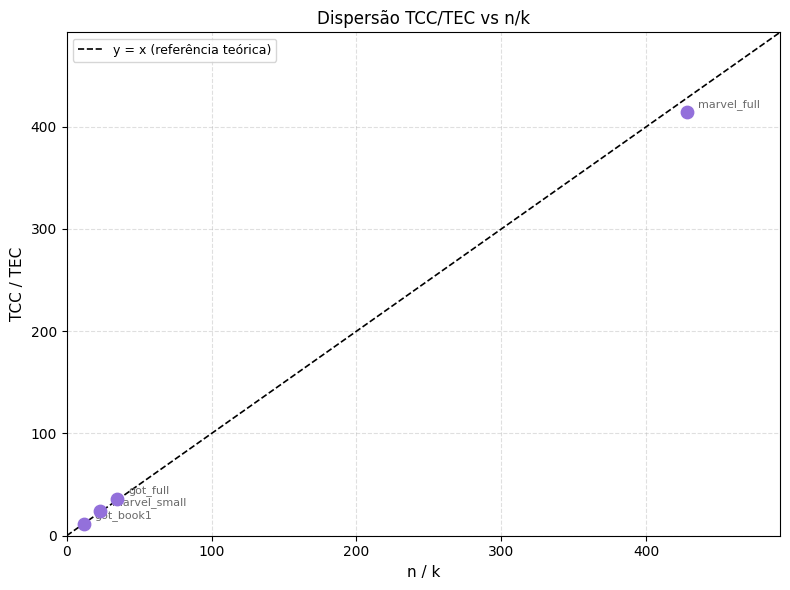

In [18]:
# ══════════════════════════════════════════════
#  SECÇÃO 4.3 — Verificação TCC/TEC ≈ n/k
# ══════════════════════════════════════════════

# ── Dados recolhidos ──
data_43 = {
    "got_book1":    {"n": g_book1.order(),  "TCC": 0.0645,   "TEC": 0.0055,  "k": 16},
    "got_full":     {"n": g_full.order(),   "TCC": 1.2651,   "TEC": 0.0349,  "k": 23},
    "marvel_small": {"n": g_msmall.order(), "TCC": 1.4298,   "TEC": 0.0593,  "k": 14},
    "marvel_full":  {"n": g_mfull.order(),  "TCC": 531.9984, "TEC": 1.2848,  "k": 15},
}

print("=" * 65)
print("Verificação TCC/TEC ≈ n/k")
print("=" * 65)
print(f"\n  {'Dataset':<15} {'n':>6} {'k':>4} {'n/k':>8} {'TCC/TEC':>10}")
print("  " + "-" * 50)

nk_vals      = []
ratio_vals   = []
ds_labels_43 = []

for ds_name, d in data_43.items():
    nk    = d["n"] / d["k"]
    ratio = d["TCC"] / d["TEC"]
    nk_vals.append(nk)
    ratio_vals.append(ratio)
    ds_labels_43.append(ds_name)
    print(f"  {ds_name:<15} {d['n']:>6} {d['k']:>4} {nk:>8.2f} {ratio:>10.2f}")


# ── Gráfico de dispersão ──
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(nk_vals, ratio_vals, color='mediumpurple', s=80, zorder=5)

# Etiqueta de cada ponto
for x, y, label in zip(nk_vals, ratio_vals, ds_labels_43):
    ax.annotate(label, (x, y),
                textcoords="offset points", xytext=(8, 4),
                fontsize=8, color='dimgray')

# Reta y = x (referência teórica)
max_val = max(max(nk_vals), max(ratio_vals)) * 1.15
ax.plot([0, max_val], [0, max_val], 'k--', linewidth=1.2, label="y = x (referência teórica)")

ax.set_xlabel("n / k", fontsize=11)
ax.set_ylabel("TCC / TEC", fontsize=11)
ax.set_title("Dispersão TCC/TEC vs n/k", fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, linestyle='--', alpha=0.4)
ax.set_xlim(0, max_val)
ax.set_ylim(0, max_val)

plt.tight_layout()
plt.show()